# ISLES 2026 — Exploratory Data Analysis
**Read-only.** No files are written except `eda_summary.json` at the end.

### What this notebook produces
| Section | Purpose | Feeds into |
|---|---|---|
| 1. Metadata audit | Chronicity / days / site distributions | CV split strategy |
| 2. Orientation audit | Axes, voxel spacing, affine sanity | Preprocessing |
| 3. Intensity audit | Per-scan histogram stats | Normalisation choice |
| 4. Lesion audit | Volume, prevalence, size stratification | Loss weighting, augmentation |
| 5. Site heterogeneity | Cross-site intensity + spacing variance | Harmonisation decision |
| 6. Summary export | `eda_summary.json` for pipeline config | `config.yaml` |

**Dataset mount path:** `/kaggle/input/atlas-raw/`

In [6]:
import os
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/ingest-atlas")

print("--- Checking Root Directory Contents ---")
if DATA_ROOT.exists():
    # Show the first 15 files/folders found inside the input mount
    for item in list(DATA_ROOT.iterdir())[:15]:
        print(f"  Found: {item}")
else:
    print(f"  Path does not exist! Let's find your inputs inside /kaggle/input:")
    for item in Path("/kaggle/input").rglob("*"):
        if "ingest-atlas" in str(item) and item.is_dir():
            print(f"  Actual Path: {item}")

--- Checking Root Directory Contents ---
  Path does not exist! Let's find your inputs inside /kaggle/input:
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_raw
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_extracted
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_raw/metadata
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_raw/images
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_raw/masks
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_extracted/Training_Raw
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_extracted/Training_Raw/R038
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_extracted/Training_Raw/R045
  Actual Path: /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_extracted/Training_Raw/R010
  Actual Path: /kaggle

In [7]:
from pathlib import Path

# Discover what Kaggle actually mounted
input_root = Path("/kaggle/input")
print("All mounted datasets:")
for ds in sorted(input_root.iterdir()):
    print(f"\n  {ds}")
    for item in sorted(ds.iterdir())[:10]:
        tag = "DIR " if item.is_dir() else "FILE"
        print(f"    {tag}  {item.name}")

All mounted datasets:

  /kaggle/input/notebooks
    DIR   josephderrick


## 0. Imports and paths

In [8]:
import json
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT    = Path("/kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_raw")
IMAGES_DIR   = DATA_ROOT / "images"
MASKS_DIR    = DATA_ROOT / "masks"
META_CSV     = DATA_ROOT / "metadata" / "metadata.csv"
INVENTORY    = DATA_ROOT / "inventory.json"
OUTPUT_DIR   = Path("/kaggle/working")

# Sanity
assert IMAGES_DIR.exists(), f"Images dir not found: {IMAGES_DIR}"
assert META_CSV.exists(),   f"Metadata CSV not found: {META_CSV}"

print(f"Images : {len(list(IMAGES_DIR.glob('*.nii.gz')))}")
print(f"Masks  : {len(list(MASKS_DIR.glob('*.nii.gz')))}")

Images : 955
Masks  : 955


## 1. Metadata audit

In [9]:
df = pd.read_csv(META_CSV)

# Derive a clean UID that matches the filename stem
# inventory.json records have uid = site__subject__session
with open(INVENTORY) as f:
    inv = json.load(f)

# Build a SESSION_ID → UID lookup from inventory
sid_to_uid = {}
for rec in inv["records"]:
    sid = f"{rec['subject']}_{rec['session']}"   # e.g. sub-r001s001_ses-1
    sid_to_uid[sid] = rec["uid"]

df["UID"] = df["SESSION_ID"].map(sid_to_uid)
missing_uid = df["UID"].isna().sum()
print(f"SESSION_ID → UID mapping: {len(df) - missing_uid} matched, {missing_uid} unmatched")

# Training-only slice for modelling
df_train = df[df["ATLAS2_DATASET"] == "Training"].copy().reset_index(drop=True)

print(f"\nFull dataset  : {len(df)} rows")
print(f"Training split: {len(df_train)} rows")
print(f"Testing split : {len(df[df['ATLAS2_DATASET'] == 'Testing'])} rows")
print(f"\nCHRONICITY_DERIVED (all):")
print(df["CHRONICITY_DERIVED"].value_counts())
print(f"\nCHRONICITY_DERIVED (training only):")
print(df_train["CHRONICITY_DERIVED"].value_counts())

SESSION_ID → UID mapping: 955 matched, 0 unmatched

Full dataset  : 955 rows
Training split: 655 rows
Testing split : 300 rows

CHRONICITY_DERIVED (all):
CHRONICITY_DERIVED
chronic     630
subacute    131
unknown     126
acute        68
Name: count, dtype: int64

CHRONICITY_DERIVED (training only):
CHRONICITY_DERIVED
chronic     426
unknown     100
subacute     82
acute        47
Name: count, dtype: int64


In [11]:
# # Build SESSION_ID → UID lookup robustly
# sid_to_uid = {}
# for rec in inv["records"]:
#     # inventory UID: R001__sub-r001s001__ses-1
#     # metadata SESSION_ID: sub-r001s001_ses-1
#     sid = f"{rec['subject']}_{rec['session']}"   # sub-r001s001_ses-1
#     sid_to_uid[sid] = rec["uid"]

# df["UID"] = df["SESSION_ID"].map(sid_to_uid)
# missing_uid = df["UID"].isna().sum()
# print(f"SESSION_ID → UID mapping: {len(df) - missing_uid} matched, {missing_uid} unmatched")

# # If still unmatched, print samples to diagnose
# if missing_uid > 0:
#     print("Sample unmatched SESSION_IDs:", df[df["UID"].isna()]["SESSION_ID"].head(5).tolist())
#     print("Sample inventory keys:", list(sid_to_uid.keys())[:5])

SESSION_ID → UID mapping: 955 matched, 0 unmatched


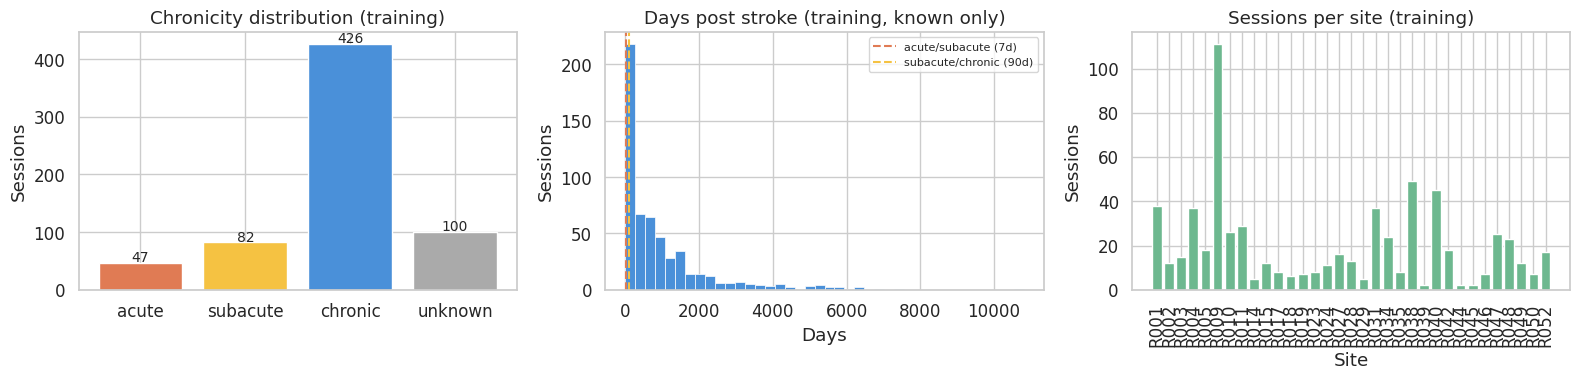


DAYS_POST_STROKE — median: 515d, mean: 955d, max: 10806d


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Chronicity distribution ───────────────────────────────────────────
order = ["acute", "subacute", "chronic", "unknown"]
chron_counts = df_train["CHRONICITY_DERIVED"].value_counts().reindex(order).fillna(0)
axes[0].bar(chron_counts.index, chron_counts.values,
            color=["#e07b54", "#f5c242", "#4a90d9", "#aaaaaa"])
axes[0].set_title("Chronicity distribution (training)")
axes[0].set_ylabel("Sessions")
for i, v in enumerate(chron_counts.values):
    axes[0].text(i, v + 2, str(int(v)), ha="center", fontsize=10)

# ── Plot 2: Days post stroke histogram ────────────────────────────────────────
days_valid = df_train["DAYS_POST_STROKE"].dropna()
axes[1].hist(days_valid, bins=40, color="#4a90d9", edgecolor="white", linewidth=0.5)
axes[1].axvline(7,  color="#e07b54", linestyle="--", linewidth=1.5, label="acute/subacute (7d)")
axes[1].axvline(90, color="#f5c242", linestyle="--", linewidth=1.5, label="subacute/chronic (90d)")
axes[1].set_title("Days post stroke (training, known only)")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Sessions")
axes[1].legend(fontsize=8)

# ── Plot 3: Sessions per site ─────────────────────────────────────────────────
site_counts = df_train["SITE"].value_counts().sort_index()
axes[2].bar(site_counts.index, site_counts.values, color="#6db88f")
axes[2].set_title("Sessions per site (training)")
axes[2].set_xlabel("Site")
axes[2].set_ylabel("Sessions")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_metadata.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nDAYS_POST_STROKE — median: {days_valid.median():.0f}d, "
      f"mean: {days_valid.mean():.0f}d, max: {days_valid.max():.0f}d")

## 2. Orientation and spacing audit
Samples a subset of scans (fast) to characterise orientation, voxel spacing, and image shape diversity.

In [17]:
def load_header_stats(nii_path: Path) -> dict:
    """Extract orientation and spacing info without loading voxel data."""
    img    = nib.load(str(nii_path))
    hdr    = img.header
    affine = img.affine
    shape  = img.shape
    zooms  = hdr.get_zooms()[:3]
    ornt   = nib.orientations.aff2axcodes(affine)

    return {
        "path":        str(nii_path),
        "shape":       shape,
        "spacing_x":   round(float(zooms[0]), 3),
        "spacing_y":   round(float(zooms[1]), 3),
        "spacing_z":   round(float(zooms[2]), 3),
        "orientation": "".join(ornt),
        "n_voxels":    int(np.prod(shape)),
    }


print(f"Auditing {len(sample_imgs)} training images for orientation/spacing ...")

header_records = []
errors = []

for p in tqdm(sample_imgs):
    try:
        header_records.append(load_header_stats(p))
    except Exception as e:
        errors.append((p.name, str(e)))

# Always report errors before asserting
if errors:
    print(f"\nErrors ({len(errors)}):")
    for name, err in errors[:10]:
        print(f"  {name}: {err}")

assert len(header_records) > 0, (
    f"All {len(sample_imgs)} scans failed to load. "
    f"First error: {errors[0] if errors else 'unknown'}"
)

df_hdr = pd.DataFrame(header_records)

print(f"\nSuccessfully loaded: {len(df_hdr)} / {len(sample_imgs)}")
print(f"\nOrientation distribution:")
print(df_hdr["orientation"].value_counts())
print(f"\nVoxel spacing (mm) — x/y/z:")
for ax in ["spacing_x", "spacing_y", "spacing_z"]:
    s = df_hdr[ax]
    print(f"  {ax}: min={s.min():.2f}  median={s.median():.2f}  max={s.max():.2f}  unique={s.nunique()}")
print(f"\nImage shape diversity (unique shapes): {df_hdr['shape'].apply(str).nunique()}")

Auditing 200 training images for orientation/spacing ...


  0%|          | 0/200 [00:00<?, ?it/s]


Successfully loaded: 200 / 200

Orientation distribution:
orientation
RAS    120
LAS     80
Name: count, dtype: int64

Voxel spacing (mm) — x/y/z:
  spacing_x: min=1.00  median=1.00  max=1.10  unique=3
  spacing_y: min=1.00  median=1.00  max=1.00  unique=1
  spacing_z: min=1.00  median=1.00  max=1.00  unique=1

Image shape diversity (unique shapes): 88


In [15]:
# ── Build training image list ─────────────────────────────────────────────────
train_uids = set(df_train["UID"].dropna())
all_images = sorted(IMAGES_DIR.glob("*.nii.gz"))

# Diagnose the stem format before filtering
sample_stems = [p.name for p in all_images[:3]]
sample_uids  = list(train_uids)[:3]
print(f"Sample image filenames : {sample_stems}")
print(f"Sample UIDs from meta  : {sample_uids}")

# Strip _T1w.nii.gz suffix to get bare UID
def img_to_uid(p: Path) -> str:
    return p.name.replace("_T1w.nii.gz", "")

train_imgs  = [p for p in all_images if img_to_uid(p) in train_uids]
sample_imgs = train_imgs[:200]

print(f"\nAll images found       : {len(all_images)}")
print(f"Training images matched: {len(train_imgs)}")
print(f"Audit sample size      : {len(sample_imgs)}")

assert len(train_imgs) > 0, \
    f"No training images matched. Check stem format above.\n" \
    f"Image stem example : '{img_to_uid(all_images[0])}'\n" \
    f"UID example        : '{sample_uids[0]}'"

Sample image filenames : ['R001__sub-r001s001__ses-1_T1w.nii.gz', 'R001__sub-r001s002__ses-1_T1w.nii.gz', 'R001__sub-r001s003__ses-1_T1w.nii.gz']
Sample UIDs from meta  : ['R003__sub-r003s003__ses-1', 'R040__sub-r040s017__ses-1', 'R010__sub-r010s002__ses-1']

All images found       : 955
Training images matched: 655
Audit sample size      : 200


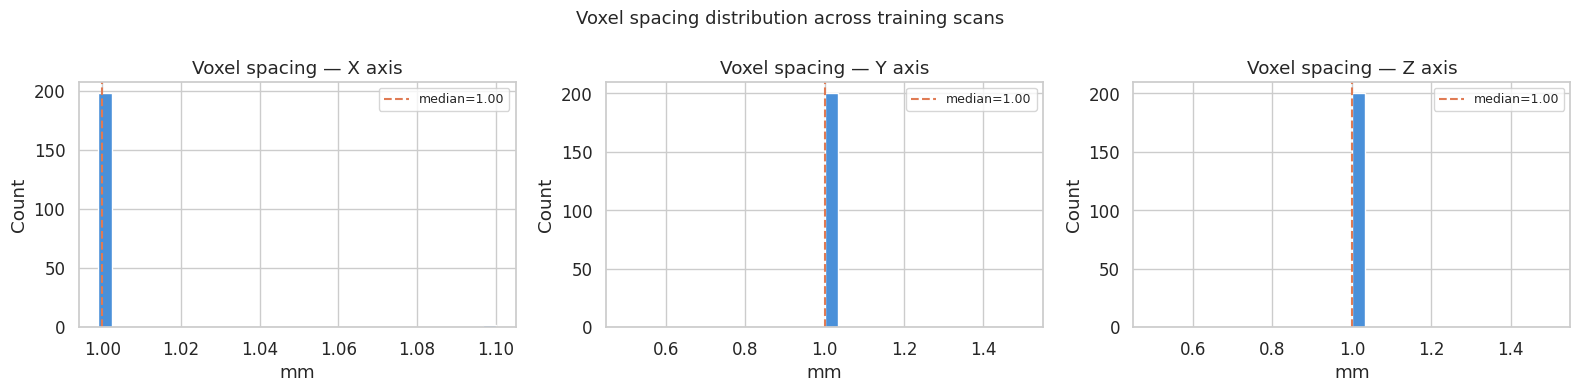

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, ax_name in enumerate(["spacing_x", "spacing_y", "spacing_z"]):
    axes[i].hist(df_hdr[ax_name], bins=30, color="#4a90d9", edgecolor="white")
    axes[i].set_title(f"Voxel spacing — {ax_name.split('_')[1].upper()} axis")
    axes[i].set_xlabel("mm")
    axes[i].set_ylabel("Count")
    axes[i].axvline(df_hdr[ax_name].median(), color="#e07b54",
                    linestyle="--", linewidth=1.5, label=f"median={df_hdr[ax_name].median():.2f}")
    axes[i].legend(fontsize=9)

plt.suptitle("Voxel spacing distribution across training scans", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_spacing.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Intensity audit
Loads voxel data for a sample of scans and measures per-scan intensity statistics.
This directly determines the normalisation strategy.

In [19]:
def load_intensity_stats(nii_path: Path) -> dict:
    """Compute foreground intensity statistics (brain voxels only, > 0)."""
    data = nib.load(str(nii_path)).get_fdata(dtype=np.float32)
    fg   = data[data > 0].ravel()
    if len(fg) == 0:
        return None
    return {
        "path":   str(nii_path),
        "mean":   float(np.mean(fg)),
        "std":    float(np.std(fg)),
        "p1":     float(np.percentile(fg, 1)),
        "p99":    float(np.percentile(fg, 99)),
        "median": float(np.median(fg)),
        "min":    float(fg.min()),
        "max":    float(fg.max()),
        "fg_voxels": len(fg),
    }


# Sample 100 training scans — loading voxels is slow on Kaggle
intensity_sample = train_imgs[:100]
print(f"Computing intensity stats for {len(intensity_sample)} scans ...")

intensity_records = []
for p in tqdm(intensity_sample):
    try:
        rec = load_intensity_stats(p)
        if rec:
            intensity_records.append(rec)
    except Exception as e:
        print(f"  WARN: {p.name} — {e}")

df_int = pd.DataFrame(intensity_records)

print(f"\nIntensity statistics across {len(df_int)} scans (foreground voxels):")
print(df_int[["mean", "std", "median", "p1", "p99"]].describe().round(1))

Computing intensity stats for 100 scans ...


  0%|          | 0/100 [00:00<?, ?it/s]


Intensity statistics across 100 scans (foreground voxels):
         mean     std  median     p1     p99
count   100.0   100.0   100.0  100.0   100.0
mean   1138.9   462.5  1205.2  147.6  1926.7
std    1162.1   460.5  1232.4  155.4  1928.9
min     117.1    53.1   121.0   12.0   217.0
25%     220.2    94.1   228.5   28.0   395.2
50%     332.2   137.3   350.5   46.0   563.5
75%    2374.8   989.8  2522.5  284.0  4084.5
max    3386.4  1305.1  3549.9  492.9  5333.1


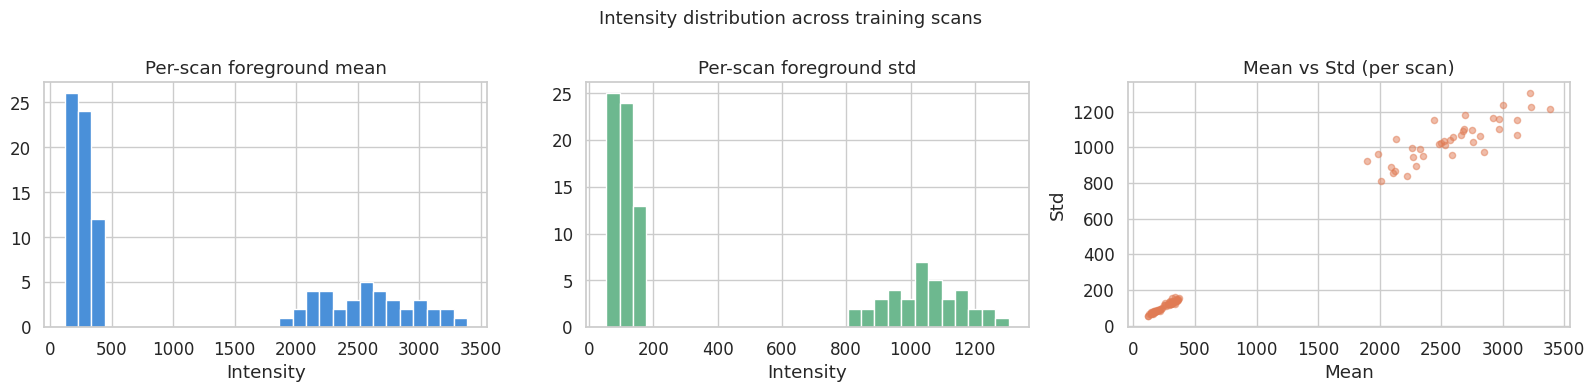


Intensity range outliers (> mean + 3σ): 0


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_int["mean"], bins=30, color="#4a90d9", edgecolor="white")
axes[0].set_title("Per-scan foreground mean")
axes[0].set_xlabel("Intensity")

axes[1].hist(df_int["std"], bins=30, color="#6db88f", edgecolor="white")
axes[1].set_title("Per-scan foreground std")
axes[1].set_xlabel("Intensity")

axes[2].scatter(df_int["mean"], df_int["std"], alpha=0.5, color="#e07b54", s=20)
axes[2].set_title("Mean vs Std (per scan)")
axes[2].set_xlabel("Mean")
axes[2].set_ylabel("Std")

plt.suptitle("Intensity distribution across training scans", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag scans with extreme intensity ranges (potential outliers)
p99_range = df_int["p99"] - df_int["p1"]
outlier_thresh = p99_range.mean() + 3 * p99_range.std()
outliers = df_int[p99_range > outlier_thresh]
print(f"\nIntensity range outliers (> mean + 3σ): {len(outliers)}")
if len(outliers):
    print(outliers[["path", "mean", "std", "p1", "p99"]].to_string())

## 4. Lesion audit
Measures lesion volume, prevalence of empty masks, and size distribution.
Critical for loss weighting and augmentation design.

In [23]:
def load_lesion_stats(img_path: Path, mask_path: Path) -> dict:
    """Compute lesion volume and voxel-level properties from mask + image pair."""
    img_nib  = nib.load(str(img_path))
    mask_nib = nib.load(str(mask_path))

    mask          = (mask_nib.get_fdata(dtype=np.float32) > 0.5).astype(np.uint8)
    zooms         = img_nib.header.get_zooms()[:3]
    voxel_vol_mm3 = float(np.prod(zooms))
    n_lesion      = int(mask.sum())
    total_voxels  = int(np.prod(mask.shape))

    return {
        "uid":             img_path.name.replace("_T1w.nii.gz", ""),
        "lesion_voxels":   n_lesion,
        "lesion_vol_mm3":  n_lesion * voxel_vol_mm3,
        "lesion_vol_ml":   n_lesion * voxel_vol_mm3 / 1000,
        "total_voxels":    total_voxels,
        "lesion_fraction": n_lesion / total_voxels if total_voxels > 0 else 0,
        "is_empty":        n_lesion == 0,
    }


lesion_records     = []
errors             = []
missing_mask_count = 0

print(f"Computing lesion stats for {len(train_imgs)} training scans ...")

# Diagnose mask path construction on first scan before the loop
test_uid       = train_imgs[0].name.replace("_T1w.nii.gz", "")
test_mask_path = MASKS_DIR / f"{test_uid}_rater1.nii.gz"
print(f"\nMask path check:")
print(f"  Image name : {train_imgs[0].name}")
print(f"  Derived UID: {test_uid}")
print(f"  Mask path  : {test_mask_path}")
print(f"  Mask exists: {test_mask_path.exists()}")

# List a few actual mask filenames for comparison
actual_masks = sorted(MASKS_DIR.glob("*.nii.gz"))[:3]
print(f"  Actual mask names: {[m.name for m in actual_masks]}")

for img_path in tqdm(train_imgs):
    uid       = img_path.name.replace("_T1w.nii.gz", "")
    mask_path = MASKS_DIR / f"{uid}_rater1.nii.gz"

    if not mask_path.exists():
        missing_mask_count += 1
        continue
    try:
        lesion_records.append(load_lesion_stats(img_path, mask_path))
    except Exception as e:
        errors.append((uid, str(e)))

if errors:
    print(f"\nLoad errors ({len(errors)}):")
    for uid, err in errors[:5]:
        print(f"  {uid}: {err}")

assert len(lesion_records) > 0, (
    f"No lesion records loaded.\n"
    f"  missing_mask_count={missing_mask_count}\n"
    f"  errors={len(errors)}\n"
    f"  First error: {errors[0] if errors else 'none'}"
)

df_les = pd.DataFrame(lesion_records)

print(f"\nLesion audit ({len(df_les)} scans):")
print(f"  Empty masks (no lesion)  : {df_les['is_empty'].sum()} "
      f"({df_les['is_empty'].mean()*100:.1f}%)")
print(f"  Missing mask files       : {missing_mask_count}")
print(f"\nLesion volume (mL) — non-empty only:")
non_empty = df_les[~df_les["is_empty"]]
print(non_empty["lesion_vol_ml"].describe().round(2))

Computing lesion stats for 655 training scans ...

Mask path check:
  Image name : R001__sub-r001s001__ses-1_T1w.nii.gz
  Derived UID: R001__sub-r001s001__ses-1
  Mask path  : /kaggle/input/notebooks/josephderrick/ingest-atlas/atlas_raw/masks/R001__sub-r001s001__ses-1_rater1.nii.gz
  Mask exists: True
  Actual mask names: ['R001__sub-r001s001__ses-1_rater1.nii.gz', 'R001__sub-r001s002__ses-1_rater1.nii.gz', 'R001__sub-r001s003__ses-1_rater1.nii.gz']


  0%|          | 0/655 [00:00<?, ?it/s]

pixdim[1,2,3] should be positive; setting to abs of pixdim values



Lesion audit (655 scans):
  Empty masks (no lesion)  : 0 (0.0%)
  Missing mask files       : 0

Lesion volume (mL) — non-empty only:
count    655.00
mean      24.42
std       46.10
min        0.01
25%        0.89
50%        3.78
75%       26.41
max      387.63
Name: lesion_vol_ml, dtype: float64


Lesion size categories:
size_cat
large (>10 mL)      240
medium (1-10 mL)    239
small (<1 mL)       176
Name: count, dtype: int64


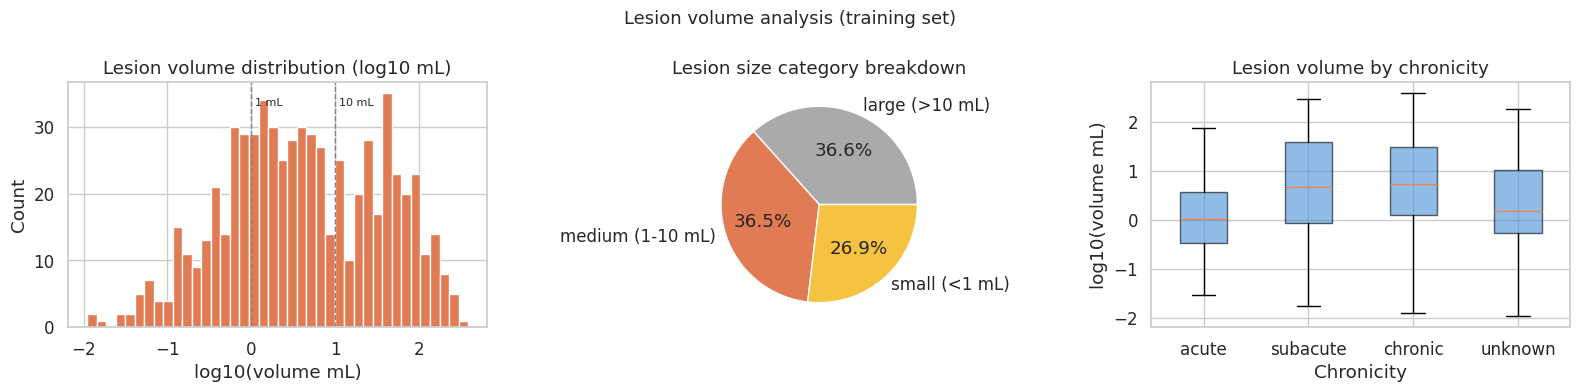

In [24]:
# Size stratification thresholds (standard in stroke literature)
# small < 1 mL, medium 1–10 mL, large > 10 mL
def size_category(vol_ml: float) -> str:
    if vol_ml == 0:   return "empty"
    if vol_ml < 1:    return "small (<1 mL)"
    if vol_ml <= 10:  return "medium (1-10 mL)"
    return "large (>10 mL)"

df_les["size_cat"] = df_les["lesion_vol_ml"].apply(size_category)
print("Lesion size categories:")
print(df_les["size_cat"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Volume histogram (log scale) ──────────────────────────────────────
vols = non_empty["lesion_vol_ml"].values
axes[0].hist(np.log10(vols + 1e-3), bins=40, color="#e07b54", edgecolor="white")
axes[0].set_title("Lesion volume distribution (log10 mL)")
axes[0].set_xlabel("log10(volume mL)")
axes[0].set_ylabel("Count")
for thresh, label in [(0, "1 mL"), (1, "10 mL")]:
    axes[0].axvline(thresh, color="grey", linestyle="--", linewidth=1)
    axes[0].text(thresh + 0.05, axes[0].get_ylim()[1]*0.9, label, fontsize=8)

# ── Plot 2: Size category pie ─────────────────────────────────────────────────
cat_counts = df_les["size_cat"].value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%",
            colors=["#aaaaaa", "#e07b54", "#f5c242", "#4a90d9"])
axes[1].set_title("Lesion size category breakdown")

# ── Plot 3: Volume by chronicity ──────────────────────────────────────────────
df_les_meta = df_les.merge(
    df_train[["UID", "CHRONICITY_DERIVED"]].rename(columns={"UID": "uid"}),
    on="uid", how="left"
)
chron_order = ["acute", "subacute", "chronic", "unknown"]
df_les_meta_ne = df_les_meta[~df_les_meta["is_empty"]]
axes[2].boxplot(
    [np.log10(df_les_meta_ne[df_les_meta_ne["CHRONICITY_DERIVED"] == c]["lesion_vol_ml"] + 1e-3)
     for c in chron_order],
    labels=chron_order, patch_artist=True,
    boxprops=dict(facecolor="#4a90d9", alpha=0.6)
)
axes[2].set_title("Lesion volume by chronicity")
axes[2].set_ylabel("log10(volume mL)")
axes[2].set_xlabel("Chronicity")

plt.suptitle("Lesion volume analysis (training set)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_lesion.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Site heterogeneity audit
Measures cross-site intensity and spacing variance — determines whether
site-level harmonisation is needed beyond per-scan normalisation.

In [25]:
# # Merge intensity stats with site labels
# df_int["uid"] = [Path(p).stem.replace("_T1w", "") for p in df_int["path"]]
# df_int_meta = df_int.merge(
#     df_train[["UID", "SITE", "CHRONICITY_DERIVED"]].rename(columns={"UID": "uid"}),
#     on="uid", how="left"
# )

# # Per-site mean intensity stats
# site_stats = (
#     df_int_meta.groupby("SITE")[["mean", "std"]]
#     .agg(["mean", "std"])
#     .round(1)
# )
# print("Per-site intensity statistics (mean ± std of per-scan means):")
# print(site_stats.to_string())

# # Inter-site coefficient of variation for intensity mean
# site_means = df_int_meta.groupby("SITE")["mean"].mean()
# cv_intensity = site_means.std() / site_means.mean()
# print(f"\nInter-site CV (intensity mean): {cv_intensity:.3f}")
# print("  > 0.15 → site-level harmonisation likely needed")
# print("  ≤ 0.15 → per-scan z-score normalisation likely sufficient")

Per-site intensity statistics (mean ± std of per-scan means):
Empty DataFrame
Columns: [(mean, mean), (mean, std), (std, mean), (std, std)]
Index: []

Inter-site CV (intensity mean): nan
  > 0.15 → site-level harmonisation likely needed
  ≤ 0.15 → per-scan z-score normalisation likely sufficient


In [29]:
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# # ── Plot 1: Per-site intensity mean boxplot ────────────────────────────────────
# sites_in_sample = sorted(df_int_meta["SITE"].dropna().unique())
# axes[0].boxplot(
#     [df_int_meta[df_int_meta["SITE"] == s]["mean"].values for s in sites_in_sample],
#     labels=sites_in_sample, patch_artist=True,
#     boxprops=dict(facecolor="#6db88f", alpha=0.6)
# )
# axes[0].set_title("Per-scan intensity mean by site")
# axes[0].set_xlabel("Site")
# axes[0].set_ylabel("Mean intensity (raw)")
# axes[0].tick_params(axis="x", rotation=90)

# # ── Plot 2: Spacing z vs site (proxy for acquisition protocol diversity) ──────
# df_hdr["uid"]  = [Path(p).stem.replace("_T1w", "") for p in df_hdr["path"]]
# df_hdr_meta = df_hdr.merge(
#     df_train[["UID", "SITE"]].rename(columns={"UID": "uid"}),
#     on="uid", how="left"
# )
# axes[1].boxplot(
#     [df_hdr_meta[df_hdr_meta["SITE"] == s]["spacing_z"].values for s in sites_in_sample],
#     labels=sites_in_sample, patch_artist=True,
#     boxprops=dict(facecolor="#f5c242", alpha=0.6)
# )
# axes[1].set_title("Z-axis voxel spacing (mm) by site")
# axes[1].set_xlabel("Site")
# axes[1].set_ylabel("Spacing Z (mm)")
# axes[1].tick_params(axis="x", rotation=90)

# plt.suptitle("Site-level heterogeneity", fontsize=13)
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "eda_site_heterogeneity.png", dpi=150, bbox_inches="tight")
# plt.show()

Intensity → metadata merge: 100 / 100 matched

Per-site intensity statistics:
        mean            std       
        mean    std    mean    std
SITE                              
R001  2583.3  384.0  1039.8  118.5
R002   172.3   38.1    78.1   14.3
R003   186.9   38.1    82.7   14.7
R004   310.1   47.3   130.3   17.9

Inter-site CV (intensity mean): 1.453
  > 0.15 → site-level harmonisation likely needed
  ≤ 0.15 → per-scan z-score normalisation likely sufficient


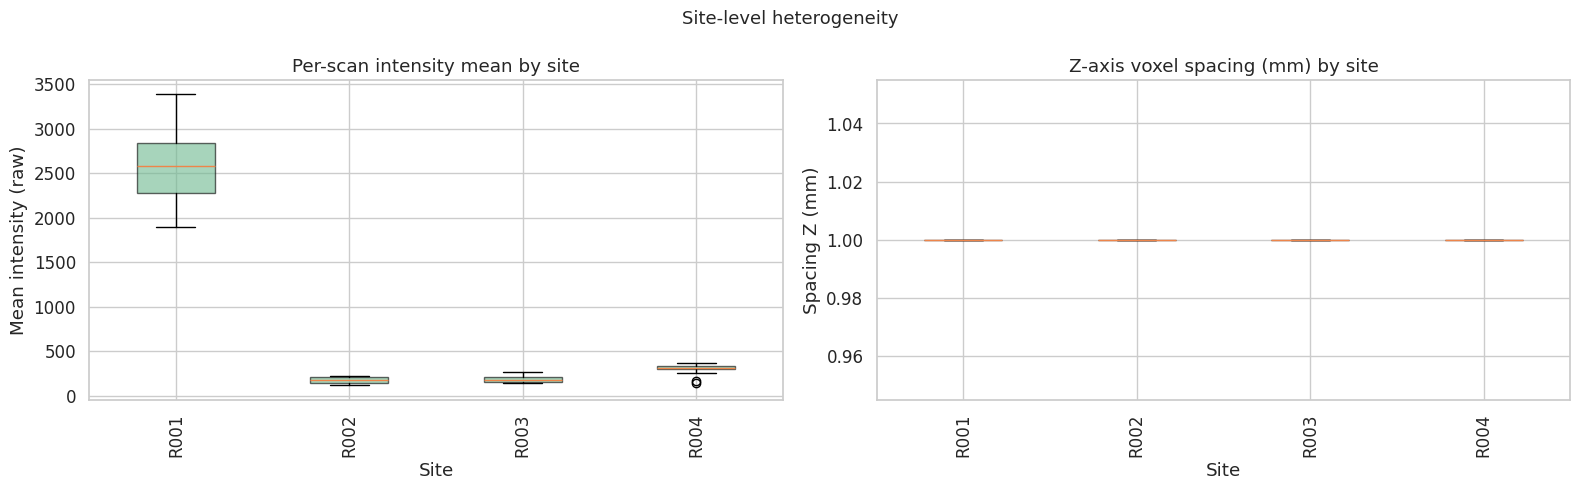

In [28]:
# ── Section 5: Site heterogeneity audit ──────────────────────────────────────

# Rebuild uid column from intensity records using consistent stripping
# Fix: strip both .nii.gz extensions correctly
df_int["uid"] = [Path(p).name.replace("_T1w.nii.gz", "") for p in df_int["path"]]

# Merge with training metadata
df_int_meta = df_int.merge(
    df_train[["UID", "SITE", "CHRONICITY_DERIVED"]].rename(columns={"UID": "uid"}),
    on="uid", how="left"
)

# Diagnose merge
n_matched = df_int_meta["SITE"].notna().sum()
print(f"Intensity → metadata merge: {n_matched} / {len(df_int_meta)} matched")
if n_matched == 0:
    print("  Sample intensity UIDs :", df_int["uid"].head(3).tolist())
    print("  Sample train UIDs     :", df_train["UID"].head(3).tolist())

assert n_matched > 0, "Merge failed — check UID format mismatch above"

# ── Per-site stats ────────────────────────────────────────────────────────────
site_stats = (
    df_int_meta.groupby("SITE")[["mean", "std"]]
    .agg(["mean", "std"])
    .round(1)
)
print("\nPer-site intensity statistics:")
print(site_stats.to_string())

site_means    = df_int_meta.groupby("SITE")["mean"].mean()
cv_intensity  = site_means.std() / site_means.mean()
print(f"\nInter-site CV (intensity mean): {cv_intensity:.3f}")
print("  > 0.15 → site-level harmonisation likely needed")
print("  ≤ 0.15 → per-scan z-score normalisation likely sufficient")

# ── Plots ─────────────────────────────────────────────────────────────────────
sites_in_sample = sorted(df_int_meta["SITE"].dropna().unique())
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Guard: only plot sites that have data
intensity_by_site = [df_int_meta[df_int_meta["SITE"] == s]["mean"].dropna().values
                     for s in sites_in_sample]
intensity_by_site = [(s, v) for s, v in zip(sites_in_sample, intensity_by_site) if len(v) > 0]
plot_sites  = [s for s, _ in intensity_by_site]
plot_values = [v for _, v in intensity_by_site]

axes[0].boxplot(plot_values, tick_labels=plot_sites, patch_artist=True,
                boxprops=dict(facecolor="#6db88f", alpha=0.6))
axes[0].set_title("Per-scan intensity mean by site")
axes[0].set_xlabel("Site")
axes[0].set_ylabel("Mean intensity (raw)")
axes[0].tick_params(axis="x", rotation=90)

# Spacing by site — rebuild from df_hdr
df_hdr["uid"] = [Path(p).name.replace("_T1w.nii.gz", "") for p in df_hdr["path"]]
df_hdr_meta   = df_hdr.merge(
    df_train[["UID", "SITE"]].rename(columns={"UID": "uid"}),
    on="uid", how="left"
)
spacing_by_site = [(s, df_hdr_meta[df_hdr_meta["SITE"] == s]["spacing_z"].dropna().values)
                   for s in plot_sites]
spacing_by_site = [(s, v) for s, v in spacing_by_site if len(v) > 0]
sp_sites  = [s for s, _ in spacing_by_site]
sp_values = [v for _, v in spacing_by_site]

axes[1].boxplot(sp_values, tick_labels=sp_sites, patch_artist=True,
                boxprops=dict(facecolor="#f5c242", alpha=0.6))
axes[1].set_title("Z-axis voxel spacing (mm) by site")
axes[1].set_xlabel("Site")
axes[1].set_ylabel("Spacing Z (mm)")
axes[1].tick_params(axis="x", rotation=90)

plt.suptitle("Site-level heterogeneity", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_site_heterogeneity.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Visual spot-check — one scan per chronicity class

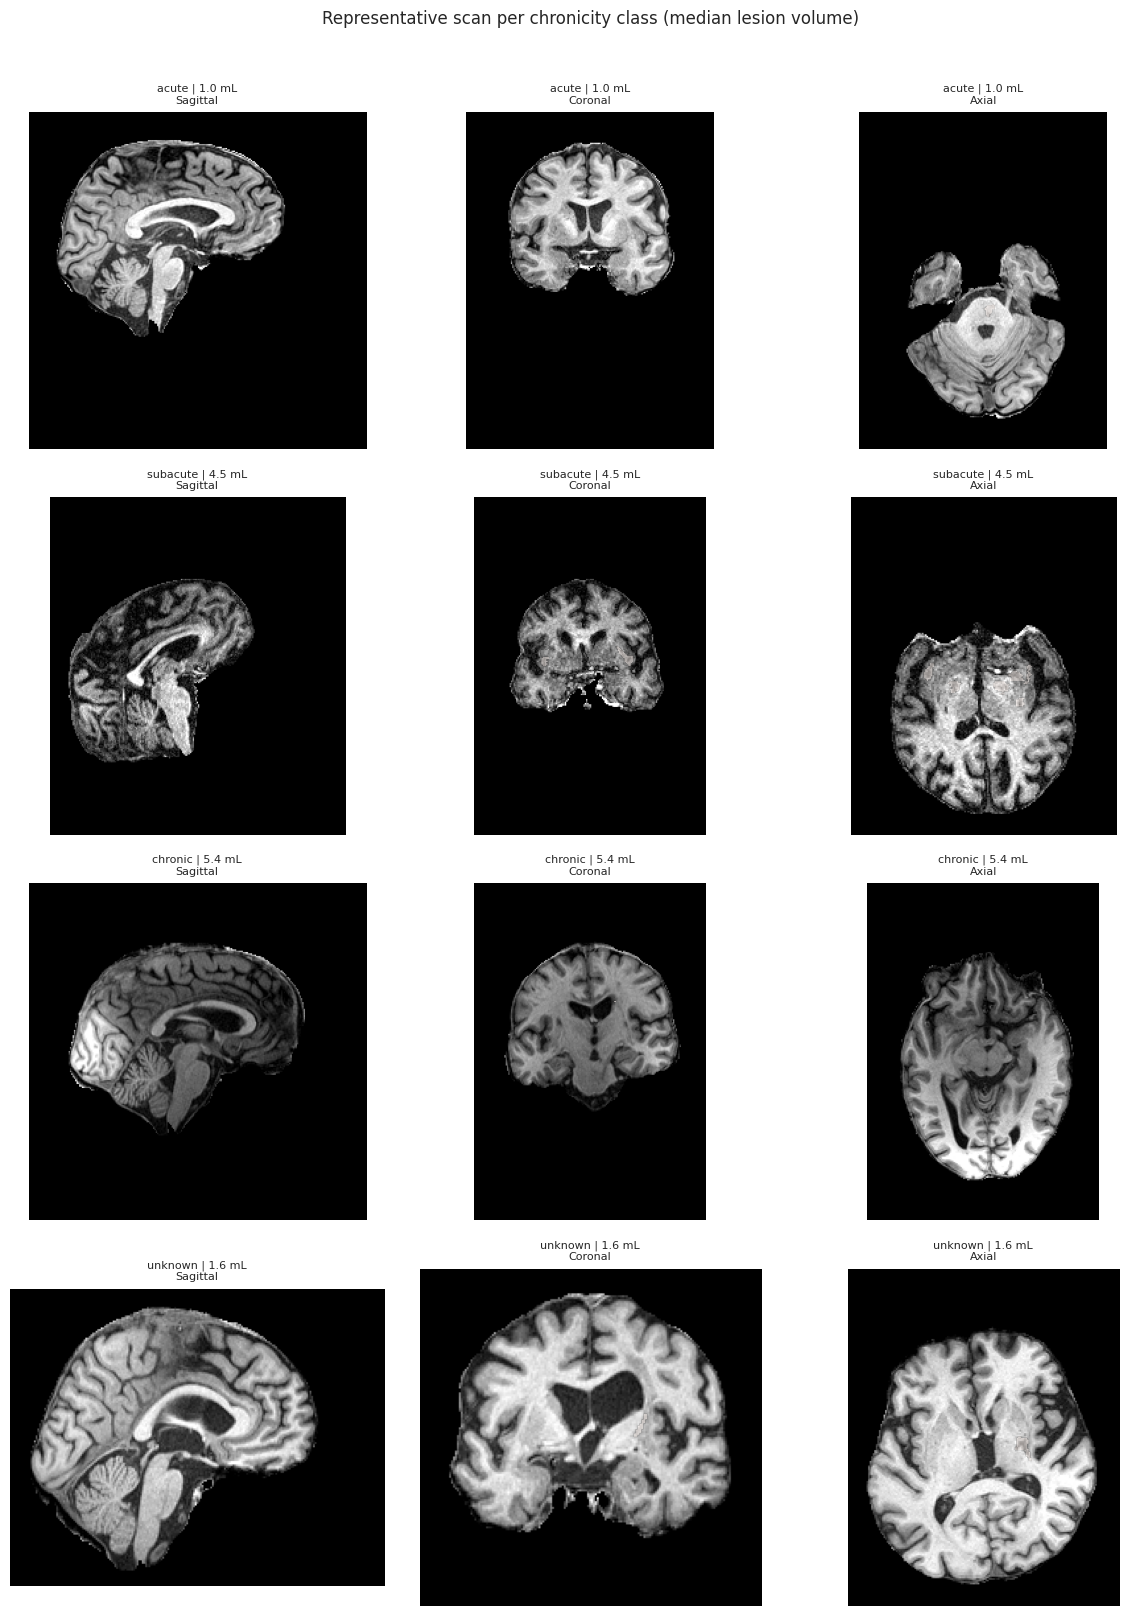

In [30]:
def show_scan_with_mask(img_path: Path, mask_path: Path,
                        title: str = "", ax_row=None) -> None:
    """Show axial/coronal/sagittal mid-slices with lesion overlay."""
    img_data  = nib.load(str(img_path)).get_fdata(dtype=np.float32)
    mask_data = nib.load(str(mask_path)).get_fdata(dtype=np.float32)

    # Normalise for display
    fg = img_data[img_data > 0]
    vmin, vmax = np.percentile(fg, 1), np.percentile(fg, 99)

    planes = [
        (img_data[img_data.shape[0]//2, :, :],  mask_data[mask_data.shape[0]//2, :, :],  "Sagittal"),
        (img_data[:, img_data.shape[1]//2, :],  mask_data[:, mask_data.shape[1]//2, :],  "Coronal"),
        (img_data[:, :, img_data.shape[2]//2],  mask_data[:, :, mask_data.shape[2]//2],  "Axial"),
    ]
    for i, (im_sl, mk_sl, plane_name) in enumerate(planes):
        ax = ax_row[i]
        ax.imshow(im_sl.T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
        if mk_sl.max() > 0:
            ax.imshow(np.ma.masked_where(mk_sl.T == 0, mk_sl.T),
                      cmap="Reds", alpha=0.5, origin="lower")
        ax.set_title(f"{title}\n{plane_name}", fontsize=8)
        ax.axis("off")


# Pick one representative scan per chronicity class
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
shown = 0
for chron in ["acute", "subacute", "chronic", "unknown"]:
    subset = df_les_meta[
        (df_les_meta["CHRONICITY_DERIVED"] == chron) &
        (~df_les_meta["is_empty"])
    ]
    if len(subset) == 0:
        continue
    # Pick the median-volume scan for representativeness
    med_idx = (subset["lesion_vol_ml"] - subset["lesion_vol_ml"].median()).abs().idxmin()
    uid     = subset.loc[med_idx, "uid"]
    img_p   = IMAGES_DIR / f"{uid}_T1w.nii.gz"
    mask_p  = MASKS_DIR  / f"{uid}_rater1.nii.gz"

    if img_p.exists() and mask_p.exists():
        vol = subset.loc[med_idx, "lesion_vol_ml"]
        show_scan_with_mask(img_p, mask_p,
                            title=f"{chron} | {vol:.1f} mL",
                            ax_row=axes[shown])
        shown += 1

plt.suptitle("Representative scan per chronicity class (median lesion volume)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_visual_spotcheck.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. EDA summary export
Serialises all key findings to `eda_summary.json`.
This file will be read by `config.yaml` and the preprocessing pipeline.

In [31]:
non_empty_vols = df_les[~df_les["is_empty"]]["lesion_vol_ml"]

eda_summary = {
    "dataset": {
        "total_sessions":    955,
        "training_sessions": int(len(df_train)),
        "testing_sessions":  int(len(df[df["ATLAS2_DATASET"] == "Testing"])),
        "n_sites":           int(df_train["SITE"].nunique()),
    },
    "chronicity": df_train["CHRONICITY_DERIVED"].value_counts().to_dict(),
    "days_post_stroke": {
        "n_known":  int(df_train["DAYS_POST_STROKE"].notna().sum()),
        "n_unknown": int(df_train["DAYS_POST_STROKE"].isna().sum()),
        "median":   float(df_train["DAYS_POST_STROKE"].median()),
        "mean":     float(df_train["DAYS_POST_STROKE"].mean()),
        "max":      float(df_train["DAYS_POST_STROKE"].max()),
    },
    "orientation": df_hdr["orientation"].value_counts().to_dict(),
    "spacing": {
        ax: {
            "min":    float(df_hdr[ax].min()),
            "median": float(df_hdr[ax].median()),
            "max":    float(df_hdr[ax].max()),
        }
        for ax in ["spacing_x", "spacing_y", "spacing_z"]
    },
    "intensity": {
        "mean_of_means":  float(df_int["mean"].mean()),
        "std_of_means":   float(df_int["mean"].std()),
        "inter_site_cv":  float(cv_intensity),
        "recommendation": "per_scan_zscore" if cv_intensity <= 0.15 else "site_harmonisation",
    },
    "lesions": {
        "empty_mask_count":    int(df_les["is_empty"].sum()),
        "empty_mask_fraction": float(df_les["is_empty"].mean()),
        "vol_ml_median":       float(non_empty_vols.median()),
        "vol_ml_mean":         float(non_empty_vols.mean()),
        "vol_ml_p10":          float(np.percentile(non_empty_vols, 10)),
        "vol_ml_p90":          float(np.percentile(non_empty_vols, 90)),
        "size_categories":     df_les["size_cat"].value_counts().to_dict(),
        "small_lesion_fraction": float((df_les["size_cat"] == "small (<1 mL)").mean()),
    },
}

summary_path = OUTPUT_DIR / "eda_summary.json"
with open(summary_path, "w") as f:
    json.dump(eda_summary, f, indent=2)

print(f"EDA summary saved: {summary_path}")
print(json.dumps(eda_summary, indent=2))

EDA summary saved: /kaggle/working/eda_summary.json
{
  "dataset": {
    "total_sessions": 955,
    "training_sessions": 655,
    "testing_sessions": 300,
    "n_sites": 33
  },
  "chronicity": {
    "chronic": 426,
    "unknown": 100,
    "subacute": 82,
    "acute": 47
  },
  "days_post_stroke": {
    "n_known": 555,
    "n_unknown": 100,
    "median": 515.0,
    "mean": 955.3279279279279,
    "max": 10806.0
  },
  "orientation": {
    "RAS": 120,
    "LAS": 80
  },
  "spacing": {
    "spacing_x": {
      "min": 0.999,
      "median": 1.0,
      "max": 1.1
    },
    "spacing_y": {
      "min": 1.0,
      "median": 1.0,
      "max": 1.0
    },
    "spacing_z": {
      "min": 1.0,
      "median": 1.0,
      "max": 1.0
    }
  },
  "intensity": {
    "mean_of_means": 1138.9184440612794,
    "std_of_means": 1162.0643726155433,
    "inter_site_cv": 1.453186290133783,
    "recommendation": "site_harmonisation"
  },
  "lesions": {
    "empty_mask_count": 0,
    "empty_mask_fraction": 0.0,


In [32]:
import zipfile
import os
from pathlib import Path
from IPython.display import FileLink, display

WORKING_DIR = Path("/kaggle/working")
ZIP_PATH    = WORKING_DIR / "isles26_eda_outputs.zip"

# Files to include — all artefacts produced by the EDA notebook
include_patterns = [
    "eda_metadata.png",
    "eda_spacing.png",
    "eda_intensity.png",
    "eda_lesion.png",
    "eda_site_heterogeneity.png",
    "eda_visual_spotcheck.png",
    "eda_summary.json",
]

print("Zipping EDA outputs ...")
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for pattern in include_patterns:
        matches = list(WORKING_DIR.glob(pattern))
        if not matches:
            print(f"  WARN: no file matched '{pattern}' — skipping")
            continue
        for f in matches:
            zf.write(f, arcname=f.name)
            print(f"  + {f.name}  ({f.stat().st_size / 1e3:.1f} KB)")

size_mb = ZIP_PATH.stat().st_size / 1e6
print(f"\nZip created: {ZIP_PATH.name}  ({size_mb:.2f} MB)")
print("Click the link below to download:\n")
display(FileLink(str(ZIP_PATH.relative_to(WORKING_DIR)), result_html_prefix="⬇ Download: "))

Zipping EDA outputs ...
  + eda_metadata.png  (93.3 KB)
  + eda_spacing.png  (53.6 KB)
  + eda_intensity.png  (74.5 KB)
  + eda_lesion.png  (105.1 KB)
  + eda_site_heterogeneity.png  (70.1 KB)
  + eda_visual_spotcheck.png  (1056.4 KB)
  + eda_summary.json  (1.3 KB)

Zip created: isles26_eda_outputs.zip  (1.33 MB)
Click the link below to download:



/kaggle/working/isles26_eda_outputs.zip

In [1]:
import json, os, subprocess
from pathlib import Path

username  = "josephderrick"          # your Kaggle username
slug      = "atlas-raw2_1-processed"      # choose a slug
proc_dir  = Path("/kaggle/working/processed")

# Write metadata file
meta = {"title": "ISLES26 Atlas-Data Processed", "id": f"{username}/{slug}",
        "licenses": [{"name": "other"}]}
with open(proc_dir / "dataset-metadata.json", "w") as f:
    json.dump(meta, f)

# Push — this creates/versions the dataset
result = subprocess.run(
    ["kaggle", "datasets", "create", "-p", str(proc_dir),
     "--dir-mode", "zip"],
    capture_output=True, text=True
)
print(result.stdout or result.stderr)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/processed/dataset-metadata.json'